In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
import pickle

import torch
from torch.utils.data import Dataset, DataLoader

# Для графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [5]:
# Загружаем данные

DATA_PATH = './'

train_df = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
dev_df = pd.read_csv(os.path.join(DATA_PATH, 'dev.csv'))
test_df = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))
sample_sub = pd.read_csv(os.path.join(DATA_PATH, 'sample_submission.csv'))

print("=== Размеры датасетов ===")
print(f"Train: {train_df.shape}")
print(f"Dev: {dev_df.shape}")
print(f"Test: {test_df.shape}")
print(f"Sample submission: {sample_sub.shape}")

print("\n=== Первые 5 строк train ===")
train_df.head()

=== Размеры датасетов ===
Train: (12553, 6)
Dev: (2265, 6)
Test: (2582, 3)
Sample submission: (9, 2)

=== Первые 5 строк train ===


,filename,transcription,spk_id,gender,ext,samplerate
0,train/0007c21c23.wav,139473,spk_E,female,wav,24000
1,train/000bee1b1d.wav,992597,spk_B,male,wav,24000
2,train/001a718902.wav,500869,spk_A,female,wav,22050
3,train/001e8e5565.wav,969908,spk_C,male,wav,22050
4,train/001ee5be6b.wav,80484,spk_E,female,wav,24000


In [6]:
# Проанализируем наши целевые переменные (уникальные числа)

unique_numbers_train = train_df['transcription'].nunique()
unique_numbers_dev = dev_df['transcription'].nunique()

print(f"Уникальных чисел в train: {unique_numbers_train:,}")
print(f"Уникальных чисел в dev: {unique_numbers_dev:,}")

# Минимум и максимум
print(f"\nДиапазон чисел в train: {train_df['transcription'].min():,} - {train_df['transcription'].max():,}")
print(f"Диапазон чисел в dev: {dev_df['transcription'].min():,} - {dev_df['transcription'].max():,}")

# Проверяем, все ли dev-числа есть в train
dev_numbers_set = set(dev_df['transcription'])
train_numbers_set = set(train_df['transcription'])
missing_in_train = dev_numbers_set - train_numbers_set

print(f"\nЧисел в dev, которых НЕТ в train: {len(missing_in_train)}")
if len(missing_in_train) > 0:
    print(f"Примеры отсутствующих чисел: {list(missing_in_train)[:10]}")
else:
    print("Все числа из dev присутствуют в train!")

# Распределение частот
freq = Counter(train_df['transcription'])
print(f"\n=== Самые частые числа в train ===")
for num, count in freq.most_common(10):
    print(f"  {num}: {count} раз(а)")

# Редкие числа (встречаются 1 раз)
rare_numbers = [num for num, count in freq.items() if count == 1]
print(f"\nЧисел, встречающихся только 1 раз: {len(rare_numbers):,} ({len(rare_numbers)/len(freq)*100:.1f}% от всех уникальных)")

Уникальных чисел в train: 12,510
Уникальных чисел в dev: 2,261

Диапазон чисел в train: 14 - 999,888
Диапазон чисел в dev: 1,363 - 999,669

Чисел в dev, которых НЕТ в train: 2245
Примеры отсутствующих чисел: [851975, 147466, 204814, 40974, 843792, 540686, 999442, 958491, 196635, 335908]

=== Самые частые числа в train ===
  222162: 3 раз(а)
  243287: 2 раз(а)
  843229: 2 раз(а)
  968621: 2 раз(а)
  497628: 2 раз(а)
  143284: 2 раз(а)
  183393: 2 раз(а)
  782752: 2 раз(а)
  85643: 2 раз(а)
  663551: 2 раз(а)

Чисел, встречающихся только 1 раз: 12,468 (99.7% от всех уникальных)


In [8]:
# Проанализируем сами аудио

# Частоты дискретизации
print("\nЧастоты дискретизации (samplerate):")
print(train_df['samplerate'].value_counts())
print(f"\nУникальных частот: {train_df['samplerate'].nunique()}")


# Пол дикторов
print("\nРаспределение по полу (gender):")
print(train_df['gender'].value_counts())

# Уникальные дикторы
print(f"\nКоличество уникальных дикторов (spk_id): {train_df['spk_id'].nunique()}")
print(f"Топ-10 дикторов по количеству записей:")
print(train_df['spk_id'].value_counts().head(10))


Частоты дискретизации (samplerate):
samplerate
24000    10424
22050     2129
Name: count, dtype: int64

Уникальных частот: 2

Распределение по полу (gender):
gender
female    7665
male      4888
Name: count, dtype: int64

Количество уникальных дикторов (spk_id): 6
Топ-10 дикторов по количеству записей:
spk_id
spk_E    5686
spk_B    2914
spk_A    1066
spk_C    1063
spk_D     913
spk_F     911
Name: count, dtype: int64


In [10]:
def number_to_russian_words(num: int) -> str:
    """
    Преобразует число в последовательность русских слов.
    Поддерживает 0 до 999 999.
    """
    if num == 0:
        return "ноль"
    
    # Словари
    units_male = ["", "один", "два", "три", "четыре", "пять", "шесть", "семь", "восемь", "девять"]
    units_female = ["", "одна", "две", "три", "четыре", "пять", "шесть", "семь", "восемь", "девять"]
    
    tens = ["", "", "двадцать", "тридцать", "сорок", "пятьдесят", 
            "шестьдесят", "семьдесят", "восемьдесят", "девяносто"]
    
    hundreds = ["", "сто", "двести", "триста", "четыреста", "пятьсот",
                "шестьсот", "семьсот", "восемьсот", "девятьсот"]
    
    teens = ["десять", "одиннадцать", "двенадцать", "тринадцать", "четырнадцать",
             "пятнадцать", "шестнадцать", "семнадцать", "восемнадцать", "девятнадцать"]
    
    def parse_hundreds(n, female=False):
        """Преобразует 1-999, female=True для тысяч"""
        if n == 0:
            return []
        
        words = []
        h = n // 100
        if h > 0:
            words.append(hundreds[h])
        
        remainder = n % 100
        if 10 <= remainder <= 19:
            words.append(teens[remainder - 10])
        else:
            t = remainder // 10
            if t > 0:
                words.append(tens[t])
            u = remainder % 10
            if u > 0:
                if female:
                    words.append(units_female[u])
                else:
                    words.append(units_male[u])
        return words
    
    words_list = []
    
    # Тысячи
    thousands = num // 1000
    if thousands > 0:
        words_list.extend(parse_hundreds(thousands, female=True))
        last_digit = thousands % 10
        last_two = thousands % 100
        if 11 <= last_two <= 19:
            words_list.append("тысяч")
        elif last_digit == 1:
            words_list.append("тысяча")
        elif 2 <= last_digit <= 4:
            words_list.append("тысячи")
        else:
            words_list.append("тысяч")
    
    # Остаток (единицы)
    remainder = num % 1000
    if remainder > 0:
        words_list.extend(parse_hundreds(remainder, female=False))
    
    return " ".join(words_list)


# Тестирование
test_numbers = [0, 1, 15, 100, 123, 1000, 2000, 280520, 999999]
for n in test_numbers:
    print(f"{n:>6,} → {number_to_russian_words(n)}")

     0 → ноль
     1 → один
    15 → пятнадцать
   100 → сто
   123 → сто двадцать три
 1,000 → одна тысяча
 2,000 → две тысячи
280,520 → двести восемьдесят тысяч пятьсот двадцать
999,999 → девятьсот девяносто девять тысяч девятьсот девяносто девять


=== Сгенерим транскрипции для наших аудио из трейна и dev ===

Train: 12553 записей, уникальных текстов: 12510
Dev: 2265 записей, уникальных текстов: 2261

Примеры транскрипций:
  139,473 → 'сто тридцать девять тысяч четыреста семьдесят три'
  992,597 → 'девятьсот девяносто две тысячи пятьсот девяносто семь'
  500,869 → 'пятьсот тысяч восемьсот шестьдесят девять'
  969,908 → 'девятьсот шестьдесят девять тысяч девятьсот восемь'
  80,484 → 'восемьдесят тысяч четыреста восемьдесят четыре'

Статистика по количеству слов в транскрипции:
  Среднее: 6.22
  Медиана: 6
  Максимум: 7
  Минимум: 1


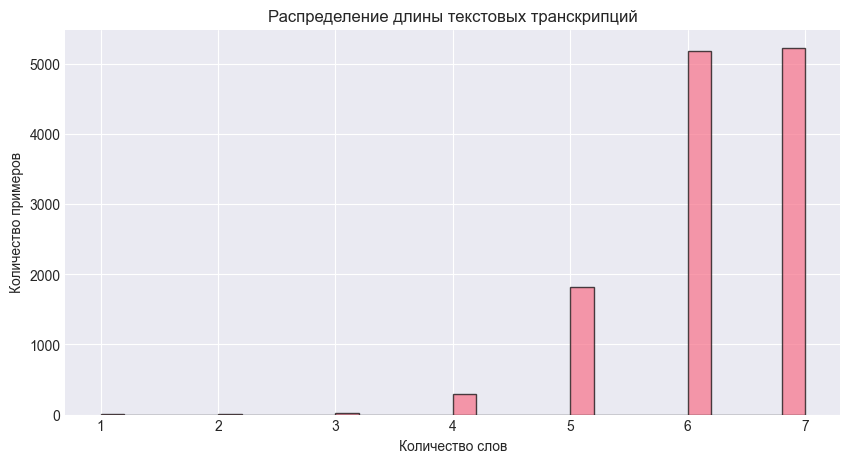

In [11]:
print("=== Сгенерим транскрипции для наших аудио из трейна и dev ===\n")

# Создаём текстовые транскрипции
train_df['text'] = train_df['transcription'].apply(number_to_russian_words)
dev_df['text'] = dev_df['transcription'].apply(number_to_russian_words)

print(f"Train: {len(train_df)} записей, уникальных текстов: {train_df['text'].nunique()}")
print(f"Dev: {len(dev_df)} записей, уникальных текстов: {dev_df['text'].nunique()}")

# Примеры
print("\nПримеры транскрипций:")
for i in range(5):
    row = train_df.iloc[i]
    print(f"  {row['transcription']:,} → '{row['text']}'")

# Статистика по длине
train_df['num_words'] = train_df['text'].str.split().str.len()
print(f"\nСтатистика по количеству слов в транскрипции:")
print(f"  Среднее: {train_df['num_words'].mean():.2f}")
print(f"  Медиана: {train_df['num_words'].median():.0f}")
print(f"  Максимум: {train_df['num_words'].max()}")
print(f"  Минимум: {train_df['num_words'].min()}")

# Гистограмма длины транскрипций
plt.figure(figsize=(10, 5))
plt.hist(train_df['num_words'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Количество слов')
plt.ylabel('Количество примеров')
plt.title('Распределение длины текстовых транскрипций')
plt.show()

In [13]:
train_df.sample(20)

,filename,transcription,spk_id,gender,ext,samplerate,text,num_words
6173,train/7cfc526be6.wav,751257,spk_E,female,wav,24000,семьсот пятьдесят одна тысяча двести пятьдесят...,7
5212,train/6ab9798cad.wav,700741,spk_A,female,wav,22050,семьсот тысяч семьсот сорок один,5
9402,train/bf187f1852.wav,680968,spk_E,female,wav,24000,шестьсот восемьдесят тысяч девятьсот шестьдеся...,6
9834,train/c852115f54.wav,264160,spk_E,female,wav,24000,двести шестьдесят четыре тысячи сто шестьдесят,6
11081,train/e14951099d.wav,88512,spk_D,female,wav,24000,восемьдесят восемь тысяч пятьсот двенадцать,5
2627,train/3561bfc2d2.wav,798666,spk_E,female,wav,24000,семьсот девяносто восемь тысяч шестьсот шестьд...,7
3303,train/425cd98972.wav,749703,spk_E,female,wav,24000,семьсот сорок девять тысяч семьсот три,6
3059,train/3d57a034eb.wav,528504,spk_E,female,wav,24000,пятьсот двадцать восемь тысяч пятьсот четыре,6
10310,train/d25e592a83.wav,211495,spk_A,female,wav,22050,двести одиннадцать тысяч четыреста девяносто пять,6
5311,train/6c4acf80f5.wav,597642,spk_E,female,wav,24000,пятьсот девяносто семь тысяч шестьсот сорок два,7


In [14]:
dev_df.sample(20)

,filename,transcription,spk_id,gender,ext,samplerate,text
1960,dev/df4038a3e2.mp3,708024,spk_I,female,mp3,16000,семьсот восемь тысяч двадцать четыре
1007,dev/7359cb5e58.wav,681149,spk_A,female,wav,16000,шестьсот восемьдесят одна тысяча сто сорок девять
462,dev/3723f85305.mp3,975130,spk_I,female,mp3,16000,девятьсот семьдесят пять тысяч сто тридцать
1877,dev/d6dafaa5eb.wav,200213,spk_J,male,wav,16000,двести тысяч двести тринадцать
2033,dev/e794ec865f.wav,840141,spk_H,male,wav,16000,восемьсот сорок тысяч сто сорок один
1791,dev/ccd2644d41.wav,24731,spk_J,male,wav,16000,двадцать четыре тысячи семьсот тридцать один
818,dev/5bae521b3b.wav,177194,spk_J,male,wav,16000,сто семьдесят семь тысяч сто девяносто четыре
59,dev/07b610494b.wav,15090,spk_A,female,wav,16000,пятнадцать тысяч девяносто
1536,dev/ad1f3102e6.mp3,897805,spk_I,female,mp3,16000,восемьсот девяносто семь тысяч восемьсот пять
2208,dev/f9bb7038f8.mp3,683853,spk_I,female,mp3,16000,шестьсот восемьдесят три тысячи восемьсот пять...


In [15]:
import pickle
from collections import Counter

class RussianTokenizer:
    """
    Токенизатор для русских слов (для CTC модели)
    """
    def __init__(self):
        self.char_to_idx = {}
        self.idx_to_char = {}
        self.vocab_size = 0
        # Специальные токены
        self.PAD_TOKEN = '<pad>'
        self.UNK_TOKEN = '<unk>'
        self.BLANK_TOKEN = '<blank>'  # для CTC
        
    def build_vocab(self, texts, min_freq=1):
        """
        texts: список строк с текстами
        min_freq: минимальная частота слова для включения в словарь
        """
        # Собираем все слова
        all_words = []
        for text in texts:
            all_words.extend(text.split())
        
        # Считаем частоты
        word_freq = Counter(all_words)
        
        # Фильтруем по частоте
        vocab_words = [word for word, freq in word_freq.items() if freq >= min_freq]
        
        # Создаём словари
        special_tokens = [self.BLANK_TOKEN, self.PAD_TOKEN, self.UNK_TOKEN]
        for i, token in enumerate(special_tokens):
            self.char_to_idx[token] = i
            self.idx_to_char[i] = token
        
        for word in sorted(vocab_words):
            if word not in self.char_to_idx:
                idx = len(self.char_to_idx)
                self.char_to_idx[word] = idx
                self.idx_to_char[idx] = word
        
        self.vocab_size = len(self.char_to_idx)
        print(f"Размер словаря: {self.vocab_size} (включая спецтокены)")
        print(f"Уникальных слов в данных: {len(word_freq)}")
        print(f"Отфильтровано (min_freq={min_freq}): {len(word_freq) - len(vocab_words)} слов удалено")
        
        return self
    
    def encode(self, text):
        """Текст → список индексов"""
        words = text.split()
        return [self.char_to_idx.get(word, self.char_to_idx[self.UNK_TOKEN]) for word in words]
    
    def decode(self, indices, remove_blanks=True):
        """Список индексов → текст"""
        if remove_blanks:
            # Убираем повторяющиеся blank'и (для CTC)
            indices = [idx for idx, _ in zip(indices, indices[1:] + [None]) if idx != self.char_to_idx[self.BLANK_TOKEN]]
        words = [self.idx_to_char.get(idx, self.UNK_TOKEN) for idx in indices]
        return " ".join(words)
    
    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump({
                'char_to_idx': self.char_to_idx,
                'idx_to_char': self.idx_to_char,
                'vocab_size': self.vocab_size
            }, f)
        print(f"Токенизатор сохранён в {path}")
    
    def load(self, path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
            self.char_to_idx = data['char_to_idx']
            self.idx_to_char = data['idx_to_char']
            self.vocab_size = data['vocab_size']
        print(f"Токенизатор загружен из {path}")
        return self


# Строим токенизатор на всех текстах
print("Построение токенизатора\n")

all_texts = list(train_df['text']) + list(dev_df['text'])
tokenizer = RussianTokenizer()
tokenizer.build_vocab(all_texts, min_freq=1)  # min_freq=1, так как данных мало

Построение токенизатора

Размер словаря: 44 (включая спецтокены)
Уникальных слов в данных: 41
Отфильтровано (min_freq=1): 0 слов удалено


In [16]:
# Тестируем
print("\nТест токенизатора:")
test_text = "двести восемьдесят тысяч пятьсот двадцать"
encoded = tokenizer.encode(test_text)
decoded = tokenizer.decode(encoded, remove_blanks=False)
print(f"Текст: {test_text}")
print(f"Индексы: {encoded}")
print(f"Декодировано: {decoded}")

# Сохраняем токенизатор для одногруппника
tokenizer.save(os.path.join(DATA_PATH, 'tokenizer.pkl'))


Тест токенизатора:
Текст: двести восемьдесят тысяч пятьсот двадцать
Индексы: [11, 5, 34, 23, 8]
Декодировано: двести восемьдесят тысяч пятьсот двадцать
Токенизатор сохранён в ./tokenizer.pkl


In [17]:
# Проверка словаря

print("=== Проверка словаря токенизатора ===\n")

# Получаем все слова из словаря (исключая спецтокены)
special_tokens = ['<pad>', '<unk>', '<blank>']
vocab_words = [word for word in tokenizer.char_to_idx.keys() if word not in special_tokens]
vocab_words.sort()

print(f"Всего слов в словаре: {len(vocab_words)}")
print("\nСписок всех слов:")
print(", ".join(vocab_words))

# Проверяем, есть ли все ожидаемые слова
expected_words = [
    "ноль", "один", "два", "три", "четыре", "пять", "шесть", "семь", "восемь", "девять",
    "одна", "две",  # формы для тысяч
    "десять", "одиннадцать", "двенадцать", "тринадцать", "четырнадцать", "пятнадцать",
    "шестнадцать", "семнадцать", "восемнадцать", "девятнадцать",
    "двадцать", "тридцать", "сорок", "пятьдесят", "шестьдесят", "семьдесят", "восемьдесят", "девяносто",
    "сто", "двести", "триста", "четыреста", "пятьсот", "шестьсот", "семьсот", "восемьсот", "девятьсот",
    "тысяча", "тысячи", "тысяч"
]

missing_words = [w for w in expected_words if w not in vocab_words]
if missing_words:
    print(f"\nОтсутствуют слова: {missing_words}")
else:
    print("\nВсе ожидаемые слова присутствуют в словаре!")

# Статистика использования слов
from collections import Counter
all_texts = list(train_df['text']) + list(dev_df['text'])
all_words = []
for text in all_texts:
    all_words.extend(text.split())

word_counts = Counter(all_words)
print("\n=== Топ-20 самых частых слов ===")
for word, count in word_counts.most_common(20):
    print(f"  {word}: {count} раз")

=== Проверка словаря токенизатора ===

Всего слов в словаре: 41

Список всех слов:
восемнадцать, восемь, восемьдесят, восемьсот, два, двадцать, две, двенадцать, двести, девяносто, девятнадцать, девять, девятьсот, десять, один, одиннадцать, одна, пятнадцать, пять, пятьдесят, пятьсот, семнадцать, семь, семьдесят, семьсот, сорок, сто, три, тридцать, тринадцать, триста, тысяч, тысяча, тысячи, четыре, четыреста, четырнадцать, шестнадцать, шесть, шестьдесят, шестьсот

Отсутствуют слова: ['ноль']

=== Топ-20 самых частых слов ===
  тысяч: 9484 раз
  тысячи: 4054 раз
  пятьсот: 3027 раз
  тридцать: 3021 раз
  шестьсот: 3008 раз
  сорок: 2997 раз
  четыреста: 2992 раз
  семьдесят: 2985 раз
  двадцать: 2975 раз
  семьсот: 2973 раз
  девятьсот: 2972 раз
  восемьсот: 2938 раз
  пятьдесят: 2929 раз
  двести: 2926 раз
  триста: 2919 раз
  шестьдесят: 2916 раз
  сто: 2912 раз
  восемьдесят: 2912 раз
  девяносто: 2902 раз
  девять: 2743 раз


In [18]:
# Добавляем "ноль" в токенизатор

# Проверяем, есть ли уже 'ноль'
if 'ноль' not in tokenizer.char_to_idx:
    # Добавляем слово "ноль"
    idx = len(tokenizer.char_to_idx)
    tokenizer.char_to_idx['ноль'] = idx
    tokenizer.idx_to_char[idx] = 'ноль'
    tokenizer.vocab_size = len(tokenizer.char_to_idx)
    print(f"Добавлено слово 'ноль' с индексом {idx}")
else:
    print("Слово 'ноль' уже есть в словаре")

# Также проверяем, нужно ли добавить 'ноль' в тексты (хотя его нет в данных)
# Это важно для полноты словаря на случай, если в тесте будет 'ноль'

print(f"\nНовый размер словаря: {tokenizer.vocab_size} (включая спецтокены)")
print(f"Реальных слов: {tokenizer.vocab_size - 3}")  # минус <pad>, <unk>, <blank>

# Сохраняем обновлённый токенизатор
tokenizer.save(os.path.join(DATA_PATH, 'tokenizer.pkl'))

# Проверяем кодирование 'ноля'
test_encoded = tokenizer.encode("ноль")
test_decoded = tokenizer.decode(test_encoded, remove_blanks=False)
print(f"\nТест кодирования 'ноль':")
print(f"  Индексы: {test_encoded}")
print(f"  Декодировано: {test_decoded}")

Добавлено слово 'ноль' с индексом 44

Новый размер словаря: 45 (включая спецтокены)
Реальных слов: 42
Токенизатор сохранён в ./tokenizer.pkl

Тест кодирования 'ноль':
  Индексы: [44]
  Декодировано: ноль


In [25]:
class SpokenNumbersDataset(Dataset):
    """
    Датасет для распознавания чисел
    """
    def __init__(self, df, tokenizer, audio_dir, target_sr=16000, max_duration=6.0, 
                 n_mfcc=40, use_augmentation=False):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.audio_dir = audio_dir
        self.target_sr = target_sr
        self.max_length = int(target_sr * max_duration)
        self.n_mfcc = n_mfcc
        self.use_augmentation = use_augmentation
        
    def __len__(self):
        return len(self.df)
    
    def _load_audio(self, file_path):
        """Загрузка и предобработка аудио"""
        try:
            # Загружаем аудио
            signal, sr = librosa.load(file_path, sr=self.target_sr)
            
            # Обрезка тишины
            signal, _ = librosa.effects.trim(signal, top_db=30)
            
            # Паддинг или обрезка до фиксированной длины
            if len(signal) > self.max_length:
                signal = signal[:self.max_length]
            elif len(signal) < self.max_length:
                pad_width = self.max_length - len(signal)
                signal = np.pad(signal, (0, pad_width), 'constant')
            
            return signal
        except Exception as e:
            print(f"Ошибка загрузки {file_path}: {e}")
            return np.zeros(self.max_length)
    
    def _extract_mfcc(self, signal):
        """Извлечение MFCC признаков"""
        mfcc = librosa.feature.mfcc(y=signal, sr=self.target_sr, n_mfcc=self.n_mfcc)
        # Добавляем дельты
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
        features = np.vstack([mfcc, delta, delta2])
        return features.T  # (time_steps, features)
    
    def _augment(self, signal):
        """Аугментация аудио (опционально и только для трейна)"""
        if not self.use_augmentation:
            return signal
        
        # Добавление шума
        if np.random.random() < 0.3:
            noise = np.random.normal(0, 0.005, len(signal))
            signal = signal + noise
        
        # Изменение скорости
        if np.random.random() < 0.2:
            speed_factor = np.random.uniform(0.9, 1.1)
            signal = librosa.effects.time_stretch(signal, rate=speed_factor)
            # Обрезаем/дополняем обратно
            if len(signal) > self.max_length:
                signal = signal[:self.max_length]
            elif len(signal) < self.max_length:
                pad_width = self.max_length - len(signal)
                signal = np.pad(signal, (0, pad_width), 'constant')
        
        return signal
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        filename = row['filename']
        
        # Проверяем, нужно ли добавлять audio_dir
        if os.path.isabs(filename) or not os.path.exists(os.path.join(self.audio_dir, filename)):
            # Пробуем разные варианты путей
            possible_paths = [
                filename,
                os.path.join(self.audio_dir, filename),  # audio_dir + filename
                os.path.join(self.audio_dir, os.path.basename(filename)),  # только имя файла
            ]
            
            audio_path = None
            for path in possible_paths:
                if os.path.exists(path):
                    audio_path = path
                    break
            
            if audio_path is None:
                print(f"Файл не найден: {filename}")
                print(f"Пробовали: {possible_paths}")
                # Возвращаем заглушку
                dummy_features = np.zeros((100, self.n_mfcc * 3))
                dummy_text = [self.tokenizer.char_to_idx.get('<blank>')]
                return {
                    'audio': torch.FloatTensor(dummy_features),
                    'text': torch.LongTensor(dummy_text),
                    'audio_length': 100,
                    'text_length': 1
                }
        else:
            audio_path = os.path.join(self.audio_dir, filename)
        
        # Загружаем аудио
        signal = self._load_audio(audio_path)
        
        # Аугментация (только для трейна)
        if self.use_augmentation:
            signal = self._augment(signal)
        
        # Извлекаем MFCC
        mfcc_features = self._extract_mfcc(signal)
        
        # Текст → индексы
        text = row['text']
        text_indices = self.tokenizer.encode(text)
        
        # Добавляем blank в конец для CTC
        text_indices = text_indices + [self.tokenizer.char_to_idx['<blank>']]
        
        return {
            'audio': torch.FloatTensor(mfcc_features),  # (time, features)
            'text': torch.LongTensor(text_indices),     # (seq_len,)
            'audio_length': mfcc_features.shape[0],     # временные шаги
            'text_length': len(text_indices)            # длина текста
        }

In [27]:
# Тестируем исправленный датасет
print("=== Тестирование исправленного Dataset ===\n")

# Проверим структуру filename
print("Примеры filename из train.csv:")
for i in range(3):
    print(f"  {train_df['filename'].iloc[i]}")

print("\nПримеры filename из dev.csv:")
for i in range(3):
    print(f"  {dev_df['filename'].iloc[i]}")

# Определяем правильный путь
print(f"\nТекущая рабочая папка: {os.getcwd()}")
DATA_PATH = './'  # или './asr_data' если в подпапке

# Проверяем существование файлов
test_file = train_df['filename'].iloc[0]
full_path = os.path.join(DATA_PATH, test_file)
print(f"\nПроверка файла: {full_path}")
print(f"Файл существует: {os.path.exists(full_path)}")

# Создаем датасет с правильным audio_dir
test_dataset = SpokenNumbersDataset(
    df=train_df.head(5),  # берем 5 файлов для теста
    tokenizer=tokenizer,
    audio_dir=DATA_PATH,  # здесь должна быть папка, содержащая train/ и dev/
    use_augmentation=False
)

test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

print("\n=== Тестирование загрузки ===")
for i, batch in enumerate(test_loader):
    print(f"\nBatch {i+1}:")
    print(f"  Аудио features: {batch['audio'].shape}")
    print(f"  Текст индексы: {batch['text'].shape}")
    print(f"  Длина аудио: {batch['audio_length']}")
    print(f"  Длина текста: {batch['text_length']}")
    
    # Декодируем первый пример в батче
    decoded = tokenizer.decode(batch['text'][0].tolist(), remove_blanks=False)
    print(f"  Декодированный текст: {decoded}")
    break

=== Тестирование исправленного Dataset ===

Примеры filename из train.csv:
  train/0007c21c23.wav
  train/000bee1b1d.wav
  train/001a718902.wav

Примеры filename из dev.csv:
  dev/0025d6d9a9.wav
  dev/0030479d60.mp3
  dev/003085d7a4.mp3

Текущая рабочая папка: /Users/polinakremneva/code/asr-2026-spoken-numbers-recognition-challenge

Проверка файла: ./train/0007c21c23.wav
Файл существует: True

=== Тестирование загрузки ===

Batch 1:
  Аудио features: torch.Size([2, 188, 120])
  Текст индексы: torch.Size([2, 8])
  Длина аудио: tensor([188, 188])
  Длина текста: tensor([8, 8])
  Декодированный текст: сто тридцать девять тысяч четыреста семьдесят три <blank>


In [31]:
# Пакетная обработка всех аудио через ваш Dataset


# Создаём папку для сохранённых признаков
features_dir = os.path.join(DATA_PATH, 'precomputed_features')
os.makedirs(features_dir, exist_ok=True)

def precompute_all_features(df, split_name, audio_dir, tokenizer, use_augmentation=False):
    """
    Прогоняет все аудио через SpokenNumbersDataset и сохраняет MFCC признаки
    
    Args:
        df: DataFrame с колонками filename, text
        split_name: 'train', 'dev' или 'test'
        audio_dir: папка с аудио (например, '.')
        tokenizer: токенизатор
        use_augmentation: нужно ли применять аугментацию (для train=True, для dev=False)
    """
    
    # Создаём временный Dataset
    temp_dataset = SpokenNumbersDataset(
        df=df,
        tokenizer=tokenizer,
        audio_dir=audio_dir,
        use_augmentation=use_augmentation  # Для train=True, для dev=False
    )
    
    # Список для сохранения метаданных
    metadata_list = []
    failed_files = []
    
    print(f"\nОбработка {split_name} ({len(df)} файлов)...")
    
    for idx in tqdm(range(len(df)), desc=f"{split_name}"):
        try:
            # Получаем данные из Dataset
            sample = temp_dataset[idx]
            
            # Получаем оригинальную строку
            row = df.iloc[idx]
            
            # Сохраняем MFCC признаки в .npy файл
            feature_filename = row['filename'].replace('/', '_').replace('.wav', '.npy').replace('.mp3', '.npy')
            feature_path = os.path.join(features_dir, feature_filename)
            np.save(feature_path, sample['audio'].numpy())
            
            # Сохраняем метаданные
            metadata_list.append({
                'original_filename': row['filename'],
                'feature_filename': feature_filename,
                'transcription': row['transcription'],
                'text': row['text'],
                'spk_id': row['spk_id'],
                'gender': row['gender'],
                'audio_length_frames': sample['audio_length'],  # количество фреймов MFCC
                'text_length_words': sample['text_length'],     # длина текста в токенах
                'feature_shape': str(sample['audio'].shape)
            })
            
        except Exception as e:
            print(f"\nОшибка на индексе {idx}, файл {df.iloc[idx]['filename']}: {e}")
            failed_files.append(row['filename'])
            continue
    
    # Сохраняем метаданные в CSV
    metadata_df = pd.DataFrame(metadata_list)
    metadata_df.to_csv(os.path.join(features_dir, f'{split_name}_metadata.csv'), index=False)
    
    # Сохраняем список неудачных файлов
    if failed_files:
        with open(os.path.join(features_dir, f'{split_name}_failed.txt'), 'w') as f:
            f.write('\n'.join(failed_files))
    
    print(f"\n{split_name}:")
    print(f"   - Успешно обработано: {len(metadata_df)} из {len(df)} файлов")
    print(f"   - Сохранено в: {features_dir}")
    if failed_files:
        print(f"   - Ошибок: {len(failed_files)} (список сохранён)")
    
    return metadata_df

In [32]:
# Обрабатываем TRAIN
# Для предвычисления аугментацию НЕ включаем, чтобы сохранить оригинальные признаки
train_metadata = precompute_all_features(
    df=train_df,
    split_name='train',
    audio_dir='.',  # текущая папка, где лежат train/, dev/, test/
    tokenizer=tokenizer,
    use_augmentation=False
)

# Обрабатываем DEV
dev_metadata = precompute_all_features(
    df=dev_df,
    split_name='dev',
    audio_dir='.',
    tokenizer=tokenizer,
    use_augmentation=False
)

print("Ура, все готово!")


Обработка train (12553 файлов)...


train: 100%|██████████| 12553/12553 [01:05<00:00, 191.90it/s]



train:
   - Успешно обработано: 12553 из 12553 файлов
   - Сохранено в: ./precomputed_features

Обработка dev (2265 файлов)...


dev: 100%|██████████| 2265/2265 [00:10<00:00, 207.73it/s]


dev:
   - Успешно обработано: 2265 из 2265 файлов
   - Сохранено в: ./precomputed_features
Ура, все готово!


In [33]:
# Быстрый Dataset для загрузки предвычисленных признаков

class FastSpokenNumbersDataset(Dataset):
    """
    Использует наш оригинальный интерфейс, но загружает из .npy файлов
    
    Вход:
        metadata_csv_path: путь к CSV с метаданными (создали выше)
        features_dir: папка с .npy файлами признаков
        tokenizer: токенизатор
        use_augmentation: применять аугментацию к признакам (для train=True)
    """
    def __init__(self, metadata_csv_path, features_dir, tokenizer, use_augmentation=False):
        self.df = pd.read_csv(metadata_csv_path)
        self.features_dir = features_dir
        self.tokenizer = tokenizer
        self.use_augmentation = use_augmentation
        
        # Для быстрого доступа к спецтокенам
        self.blank_idx = tokenizer.char_to_idx['<blank>']
        
    def __len__(self):
        return len(self.df)
    
    def _augment_features(self, features):
        """
        Аугментация в пространстве признаков (быстрее, чем аудио)
        """
        if not self.use_augmentation:
            return features
        
        # Добавление шума к MFCC
        if np.random.random() < 0.3:
            noise = np.random.normal(0, 0.05, features.shape)
            features = features + noise
        
        # Маскирование по времени (как SpecAugment)
        if np.random.random() < 0.2:
            mask_size = int(features.shape[0] * 0.1)
            if mask_size > 0 and features.shape[0] > mask_size:
                start = np.random.randint(0, features.shape[0] - mask_size)
                features[start:start+mask_size, :] = 0
        
        # Маскирование по частотам
        if np.random.random() < 0.2:
            freq_mask_size = int(features.shape[1] * 0.1)
            if freq_mask_size > 0:
                freq_start = np.random.randint(0, features.shape[1] - freq_mask_size)
                features[:, freq_start:freq_start+freq_mask_size] = 0
        
        return features
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Загружаем готовые признаки
        feature_path = os.path.join(self.features_dir, row['feature_filename'])
        features = np.load(feature_path).astype(np.float32)
        
        # Аугментация (только для train)
        features = self._augment_features(features)
        
        # Текст → индексы (читаем из сохранённого text или из transcription)
        if 'text' in row:
            text = row['text']
        else:
            # Если нет текста в метаданных, берём из transcription
            text = number_to_russian_words(row['transcription'])
        
        text_indices = self.tokenizer.encode(text)
        
        # Добавляем blank в конец для CTC
        text_indices = text_indices + [self.blank_idx]
        
        return {
            'audio': torch.FloatTensor(features),          # (time, features)
            'text': torch.LongTensor(text_indices),       # (seq_len,)
            'audio_length': features.shape[0],            # временные шаги
            'text_length': len(text_indices)              # длина текста
        }

In [34]:
# Загружаем метаданные
train_metadata_path = os.path.join(features_dir, 'train_metadata.csv')
fast_dataset = FastSpokenNumbersDataset(
    metadata_csv_path=train_metadata_path,
    features_dir=features_dir,
    tokenizer=tokenizer,
    use_augmentation=False
)

print(f"Размер датасета: {len(fast_dataset)}")
print(f"Пример загрузки:")

sample = fast_dataset[0]
print(f"  audio shape: {sample['audio'].shape}")  # (time, 120)
print(f"  text shape: {sample['text'].shape}")
print(f"  audio_length: {sample['audio_length']}")
print(f"  text_length: {sample['text_length']}")
print(f"  text decoded: {tokenizer.decode(sample['text'].tolist(), remove_blanks=False)}")

# Проверка скорости
import time
start = time.time()
for i in range(100):
    _ = fast_dataset[i]
end = time.time()
print(f"\nСкорость загрузки: {(end-start)/100*1000:.2f} мс на образец")

Размер датасета: 12553
Пример загрузки:
  audio shape: torch.Size([188, 120])
  text shape: torch.Size([8])
  audio_length: 188
  text_length: 8
  text decoded: сто тридцать девять тысяч четыреста семьдесят три <blank>

Скорость загрузки: 0.35 мс на образец


In [ ]:
# Создаем папку для подготовленных данных
processed_dir = os.path.join(DATA_PATH, 'processed')
os.makedirs(processed_dir, exist_ok=True)

# Сохраняем DataFrame с текстовыми транскрипциями
train_df.to_csv(os.path.join(processed_dir, 'train_with_text.csv'), index=False)
dev_df.to_csv(os.path.join(processed_dir, 'dev_with_text.csv'), index=False)
test_df.to_csv(os.path.join(processed_dir, 'test.csv'), index=False)

print(f"Сохранены CSV файлы с текстовыми транскрипциями в {processed_dir}")

# Сохраняем информацию о датасете
dataset_info = {
    'num_train_samples': len(train_df),
    'num_dev_samples': len(dev_df),
    'num_test_samples': len(test_df),
    'vocab_size': tokenizer.vocab_size,
    'unique_numbers_train': unique_numbers_train,
    'unique_numbers_dev': unique_numbers_dev,
    'max_audio_duration': 6.0,
    'target_sr': 16000,
    'n_mfcc': 40,
    'sample_submission': sample_sub.to_dict() if sample_sub is not None else None
}

import json
with open(os.path.join(processed_dir, 'dataset_info.json'), 'w') as f:
    json.dump(dataset_info, f, indent=2)

print(f"Сохранена информация о датасете")

print(f"""
1. Папка с аудиофайлами: {DATA_PATH}/train, {DATA_PATH}/dev
2. CSV файлы с текстовыми транскрипциями: {processed_dir}/train_with_text.csv
3. Токенизатор: {processed_dir}/../tokenizer.pkl
4. Информация о датасете: {processed_dir}/dataset_info.json
""")

Сохранены CSV файлы с текстовыми транскрипциями в ./processed
Сохранена информация о датасете

1. Папка с аудиофайлами: .//train, .//dev
2. CSV файлы с текстовыми транскрипциями: ./processed/train_with_text.csv
3. Токенизатор: ./processed/../tokenizer.pkl
4. Информация о датасете: ./processed/dataset_info.json

